# Terrain, contours and connected water

An original geospatial extension inspired by **Tidal Garden Ocean Guide**, Sonia,
[catalog](https://github.com/magiccreator-ai/awesome-gpt-6-astra#tidal-garden-ocean-guide) ·
[creator post](https://x.com/sonia_code/status/2100517619778593231).
[Orbit our terrain scene](https://jltobias.github.io/JupyterLite-Astra-demos/demos/?scene=terrain).

**Learn:** connect a raster, contour map, slope field and 3D surface.
**Predict:** is every cell below sea level reachable from the sea?
All elevations and coordinates below are synthetic, in meters. This static connectivity model
excludes rainfall, tides, drainage, barriers smaller than a cell, and water dynamics.


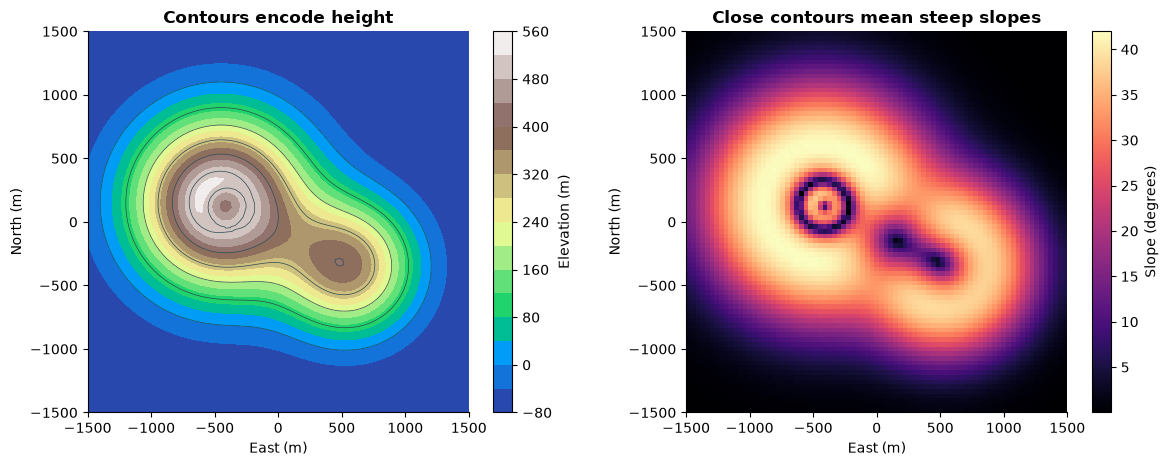

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from astra_utils import style
style()
axis = np.linspace(-1500, 1500, 81)
X, Y = np.meshgrid(axis, axis)
Z = (680*np.exp(-((X+450)**2+(Y-150)**2)/650**2)
     + 440*np.exp(-((X-550)**2+(Y+350)**2)/500**2)
     - 180*np.exp(-((X+420)**2+(Y-130)**2)/150**2) - 80)
spacing = axis[1] - axis[0]
dz_dy, dz_dx = np.gradient(Z, spacing, spacing)
slope = np.rad2deg(np.arctan(np.hypot(dz_dx, dz_dy)))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
im = axes[0].contourf(X, Y, Z, levels=16, cmap='terrain')
axes[0].contour(X, Y, Z, levels=[0, 100, 200, 300, 400, 500], colors='#294a50', linewidths=.5)
fig.colorbar(im, ax=axes[0], label='Elevation (m)')
im = axes[1].imshow(slope, origin='lower', extent=[-1500,1500,-1500,1500], cmap='magma')
fig.colorbar(im, ax=axes[1], label='Slope (degrees)')
for ax, title in zip(axes, ['Contours encode height', 'Close contours mean steep slopes']):
    ax.set(title=title, xlabel='East (m)', ylabel='North (m)', aspect='equal')
fig.tight_layout()
plt.show()


A raster stores one height per cell. `gradient` divides height differences by the **meter spacing**;
omitting that spacing silently changes the slope. Water membership also needs topology:
a low basin surrounded by high ground is different from a low cell connected to the boundary.
We use four-neighbor connectivity and seed water at the domain edge.


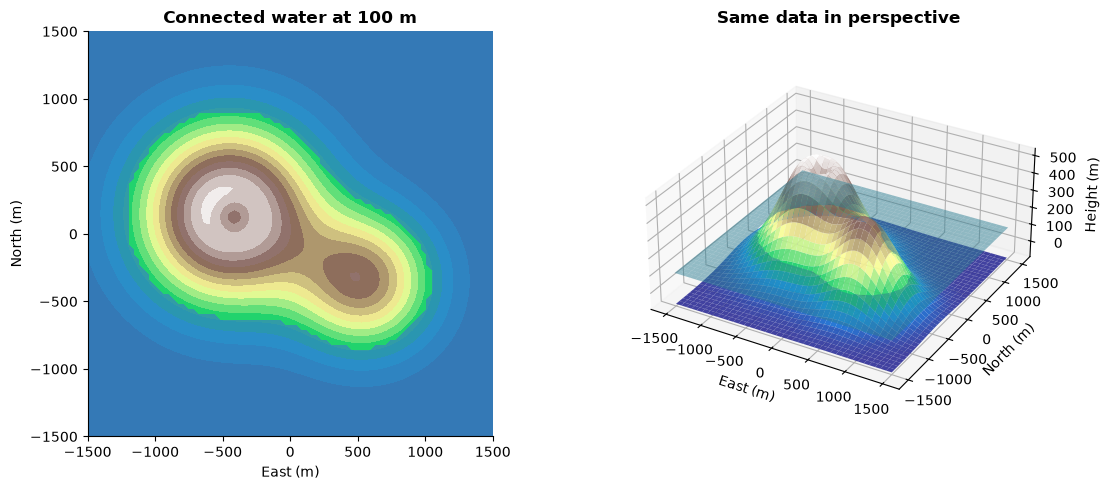

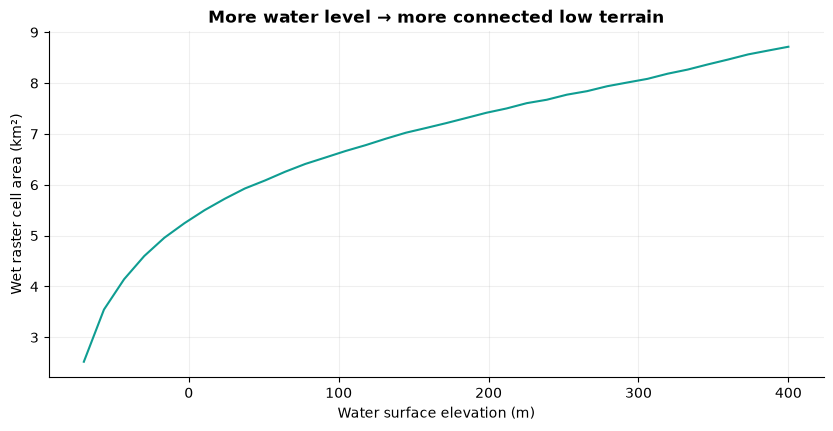

In [2]:
def connected_water(height, level):
    low = height <= level
    wet = np.zeros_like(low)
    queue = deque()
    for r, c in np.argwhere(low):
        if r in (0, height.shape[0]-1) or c in (0, height.shape[1]-1):
            wet[r, c] = True
            queue.append((r, c))
    while queue:
        r, c = queue.popleft()
        for nr, nc in [(r-1,c),(r+1,c),(r,c-1),(r,c+1)]:
            if 0 <= nr < height.shape[0] and 0 <= nc < height.shape[1] and low[nr,nc] and not wet[nr,nc]:
                wet[nr,nc] = True
                queue.append((nr,nc))
    return wet

level = 100  # Try 0, 100 and 250 m, then rerun this cell.
wet = connected_water(Z, level)
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(121)
ax.contourf(X, Y, Z, levels=16, cmap='terrain')
ax.contourf(X, Y, np.ma.masked_where(~wet, wet), levels=[.5,1.5], colors=['#398aba'], alpha=.75)
ax.set(title=f'Connected water at {level} m', xlabel='East (m)', ylabel='North (m)', aspect='equal')
ax = fig.add_subplot(122, projection='3d')
ax.plot_surface(X, Y, Z, cmap='terrain', rstride=2, cstride=2, alpha=.92)
ax.plot_surface(X, Y, np.where(wet, float(level), np.nan), color='#3ca6c1', alpha=.5)
ax.set(title='Same data in perspective', xlabel='East (m)', ylabel='North (m)', zlabel='Height (m)')
ax.set_box_aspect((1,1,.45))
fig.tight_layout()
plt.show()
levels = np.linspace(-70, 400, 36)
area_km2 = np.array([connected_water(Z, h).sum()*spacing**2/1e6 for h in levels])
plt.plot(levels, area_km2)
plt.xlabel('Water surface elevation (m)')
plt.ylabel('Wet raster cell area (km²)')
plt.title('More water level → more connected low terrain')
plt.grid(alpha=.2)
plt.show()
assert np.all(np.diff(area_km2) >= 0)
assert np.all(Z[wet] <= level)


**Read the evidence:** blue marks boundary-connected cells; the curve measures their cell area.
A sudden increase can occur when water reaches a pass into another basin. The 3D view uses
an illustrative aspect ratio, so judge numerical slope from the slope map, not apparent steepness.

**Experiment:** halve the grid resolution and compare wet area. Explain differences near the boundary.
**Check your understanding:** changing the color palette cannot alter the computed area.
This is a teaching model, not a flood forecast or a map of a real coastline.
